<a href="https://colab.research.google.com/github/dwililiya07/sentiment-analysis-review-prime/blob/main/Sentimen_Analisis_Review_PrimeVideo_10000_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Studi Kasus: Sentimen Analisis Review aplikasi prime video di Google Play Store

Pada proyek ini akan di analisis sentimen atau perasaan yang diungkapkan pengguna dalam ulasan atau review mereka di Google Play Store. Tujuannya bisa sebagai bahan evaluasi tim pengembang prime video dari proses pemahaman ulasan-ulasan penggunakan yang cenderung positif, negatif, atau netral dari aplikasi Prime Video. Dataset yang diperoleh diambil dari proses scraping yang diurutkan berdasarkan tanggal terbaru untuk menghindari ulasan bias yang sudah tidak relevan. Data yang dikumpulkan sebanyak 10000 data.


In [ ]:
!pip install sastrawi

In [ ]:
# import library yang dibutuhkan
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re # modul untuk ekspresi reguler
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
prime_reviews_df = pd.read_csv('/content/drive/MyDrive/Laskar AI Projects/Proyek_Analisis_Sentimen/reviews_primevideo.csv')
prime_reviews_df.head()

,content,score,at,thumbsUpCount
0,kenapa saat memutar film yang saya tonton laya...,2,2025-05-06 05:38:15,0
1,"Ngga bisa daftar, selalu muncul kesalahan inte...",1,2025-05-05 17:07:01,0
2,nonton,1,2025-05-05 13:32:18,0
3,Ok,5,2025-05-05 13:18:29,0
4,tolol login aja kaga bjsa,1,2025-05-05 09:07:43,0


In [ ]:
prime_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content        15000 non-null  object
 1   score          15000 non-null  int64 
 2   at             15000 non-null  object
 3   thumbsUpCount  15000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 468.9+ KB


Tidak ada nilai null, nice!!

In [ ]:
# drop duplicate
cleaned_reviews = prime_reviews_df.drop_duplicates()
cleaned_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content        15000 non-null  object
 1   score          15000 non-null  int64 
 2   at             15000 non-null  object
 3   thumbsUpCount  15000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 468.9+ KB


In [ ]:
cleaned_reviews['score'].value_counts()

,count
score,
1,7907
5,4385
2,925
3,893
4,890


## PreProcessing Text

In [ ]:
cleaned_reviews.tail(10)

,content,score,at,thumbsUpCount
14990,Woy saya sudah daftar paket prime video pas da...,1,2022-10-09 03:04:35,0
14991,Ini aplikasi penipu. Sudah berlangganan tekoms...,1,2022-10-09 02:56:44,0
14992,"Download karna sepaket sama paket telkomsel, g...",1,2022-10-09 01:35:48,0
14993,Hrs bayar mulu,1,2022-10-09 01:19:22,0
14994,Piece of sh1ttt,1,2022-10-09 00:37:49,0
14995,subtitle kacau!!!,2,2022-10-08 22:25:44,0
14996,"Film nya msh sedikit.. bnyakin lagi donk.,...",5,2022-10-08 20:37:20,0
14997,Versi PCnya tolong bagian downloadnya diperbai...,1,2022-10-08 20:12:52,0
14998,"filmnya dikit banget,bagusan disney+ dripada ini.",1,2022-10-08 18:19:12,0
14999,"Sudah berlangganan, Error Login..",1,2022-10-08 17:59:40,0


In [ ]:
# define function to preprocessing text

# 1. emoticon to text
def convert_emoticon(text):
    # dictionary emoticon ke teks dekriptif
    emoticon_dict = {
        r':\)': 'senang',
        r':D': 'sangat senang',
        r':\(': 'sedih',
        r':P': 'bercanda',
        r'<3': 'cinta',
        r'😊': 'senang',
        r'😔': 'sedih',
        r'😂': 'tertawa',
        r'👍': 'positif',
        r'👎': 'negatif',
        r'🤍': 'suka',
        r'😍': 'sangat suka',
        r'😘': 'cium',
        r'😎': 'keren',
        r'😭': 'menangis'
    }
    for emot, deskripsi in emoticon_dict.items():
      text = re.sub(re.escape(emot), f' {deskripsi}', text)
    return text

# 2. cleaning text
def cleaning(text):
    # cleaning
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # remove mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]+', '', text)        # remove RT
    text = re.sub(r"http\S+|www.\S+", '', text) # remove url
    text = re.sub(r'[0-9]+', '', text)        # remove number
    text = re.sub(r'[^\w\s]', '', text)       # remove character non-alphabet
    text = re.sub(r'(.)\1{2,}', r'\1', text)  # remove repeated char
    text = text.replace('\n', ' ').strip()  # remove newline and space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuation marks
    return text

# 3. lowercase
def caseFolding(text):
    text = text.lower()
    return text

# 4. slang words
slangwords = {
    "@": "di", "abis": "habis", "masi": "masih", "uda": "telah", "mantep": "mantap",
    "tp": "tapi", "bs":"bisa", "nggk": "tidak", "gk": "tidak", "bgt": "banget", "maks": "maksimal",
    "ga": "tidak", "gak": "tidak", "ngga": "tidak", "nggak": "tidak", "dr": "dari", "skli": "sekali",
    "kureng": "kurang", "apk": "aplikasi", "gabisa": "tidak bisa", "gatau": "tidak tahu", "gausah": "tidak perlu",
    "kemaren": "kemarin", "slmt": "selamat", "kbnyakan": "kebanyakan", "dgn": "dengan", "syaa": "saya", "ratarata": "kebanyakan",
    "mulu": "terus", "moga": "semoga", "ba gus": "bagus", "ruwet": "rumit"

}

def fixSlangwords(text, slang_dict=slangwords):
    words = text.split()
    fixed_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(fixed_words)

# 5. tokenizing
def tokenizing(text):
    text = word_tokenize(text)
    return text

# 6. filter stopwords
def filtering(text):
    # gabungan stopwords
    list_stopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
    tambahan = {"sih", "deh", "dong", "aja", "nih", "mah", "nya", "nyaa", "banget", "nya", "lah", "loo"}
    list_stopwords.update(tambahan)

    # drop stopwords penting dari list
    list_stopwords -= {"tidak","banyak", "begitu", "mau","bisa","kemarin", "hanya",
                      "tapi", "belum","sudah", "kurang"}
    filtered = []
    for txt in text:
      if txt not in list_stopwords:
        filtered.append(txt)
    text = filtered
    return text

# 7. stemming
# setup stemmer sastrawi
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming(list_words):
    # implement stemming
    stemmed_words = [stemmer.stem(word) for word in list_words]

    # combining words
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

# def toSentence(list_words):
#     sentence = ' '.join(word for word in list_words)
#     return sentence



In [ ]:
# apply to dataframe
cleaned_reviews['text_no_emoticon'] = cleaned_reviews['content'].apply(convert_emoticon)
cleaned_reviews['text_clean'] = cleaned_reviews['text_no_emoticon'].apply(cleaning)
cleaned_reviews['text_case_folding'] = cleaned_reviews['text_clean'].apply(caseFolding)
cleaned_reviews['text_slangwords'] = cleaned_reviews['text_case_folding'].apply(fixSlangwords)
cleaned_reviews['text_tokenizing'] = cleaned_reviews['text_slangwords'].apply(tokenizing)
cleaned_reviews['text_stopword'] = cleaned_reviews['text_tokenizing'].apply(filtering)
cleaned_reviews['text_stemming'] = cleaned_reviews['text_stopword'].apply(stemming)
# cleaned_reviews['text_akhir'] = cleaned_reviews['text_stemming'].apply(toSentence)

cleaned_reviews.head()


,content,score,at,thumbsUpCount,text_no_emoticon,text_clean,text_case_folding,text_slangwords,text_tokenizing,text_stopword,text_stemming,label
0,kenapa saat memutar film yang saya tonton laya...,-3,2025-05-06 05:38:15,0,kenapa saat memutar film yang saya tonton laya...,kenapa saat memutar film yang saya tonton laya...,kenapa saat memutar film yang saya tonton laya...,kenapa saat memutar film yang saya tonton laya...,"[kenapa, saat, memutar, film, yang, saya, tont...","[memutar, film, tonton, layar, hitam, subtittl...",putar film tonton layar hitam subtittl suara t...,negatif
1,"Ngga bisa daftar, selalu muncul kesalahan inte...",-11,2025-05-05 17:07:01,0,"Ngga bisa daftar, selalu muncul kesalahan inte...",Ngga bisa daftar selalu muncul kesalahan inter...,ngga bisa daftar selalu muncul kesalahan inter...,tidak bisa daftar selalu muncul kesalahan inte...,"[tidak, bisa, daftar, selalu, muncul, kesalaha...","[tidak, bisa, daftar, muncul, kesalahan, inter...",tidak bisa daftar muncul salah internal negati...,negatif
2,nonton,0,2025-05-05 13:32:18,0,nonton,nonton,nonton,nonton,[nonton],[nonton],nonton,netral
3,Ok,4,2025-05-05 13:18:29,0,Ok,Ok,ok,ok,[ok],[ok],ok,positif
4,tolol login aja kaga bjsa,-5,2025-05-05 09:07:43,0,tolol login aja kaga bjsa,tolol login aja kaga bjsa,tolol login aja kaga bjsa,tolol login aja kaga bjsa,"[tolol, login, aja, kaga, bjsa]","[tolol, login, kaga, bjsa]",tolol login kaga bjsa,negatif


#

In [ ]:
cleaned_reviews.to_csv("prime_cleaned_reviews.csv", index=False)

## Pelabelan

In [ ]:
# import library
import csv
import requests
from io import StringIO

In [ ]:
# baca kamus positif dari github
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')
  for row in reader:
    lexicon_positive[row[0]] = int(row[1])
else:
  print("Failed to fetch positive lexicon data")

# baca kamus negatif dari github
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')
  for row in reader:
    lexicon_negative[row[0]] = int(row[1])
else:
  print("Failed to fetch negative lexicon data")

In [ ]:
# fungsi pelabelan sentimen
def label_sentiment_reviews(text):
    total_score = 0

    for word in text:
      if (word in lexicon_positive):
        total_score += lexicon_positive[word]
      elif (word in lexicon_negative):
        total_score += lexicon_negative[word]

    label = ''

    # menentukan label berdasarkan skor
    if total_score > 0:
      label = 'positif'
    elif total_score < 0:
      label = 'negatif'
    else:
      label = 'netral'

    return total_score, label

In [ ]:
results = cleaned_reviews['text_stopword'].apply(label_sentiment_reviews)
results = list(zip(*results))
cleaned_reviews['score'] = results[0]
cleaned_reviews['label'] = results[1]
print(cleaned_reviews['label'].value_counts())

label
negatif    6801
positif    6235
netral     1964
Name: count, dtype: int64


Pada DataFrame cleaned_reviews, terdapat 6801 teks dengan label negatif, ada 6235 teks dengan positif, dan ada 1964 teks dengan label netral.
Selanjutnya melakukan eksplorasi data label.

In [ ]:
cleaned_reviews.tail(10)

,content,score,at,thumbsUpCount,text_no_emoticon,text_clean,text_case_folding,text_slangwords,text_tokenizing,text_stopword,text_stemming,label
14990,Woy saya sudah daftar paket prime video pas da...,1,2022-10-09 03:04:35,0,Woy saya sudah daftar paket prime video pas da...,Woy saya sudah daftar paket prime video pas da...,woy saya sudah daftar paket prime video pas da...,woy saya sudah daftar paket prime video pas da...,"[woy, saya, sudah, daftar, paket, prime, video...","[woy, sudah, daftar, paket, prime, video, pas,...",woy sudah daftar paket prime video pas daftar ...,positif
14991,Ini aplikasi penipu. Sudah berlangganan tekoms...,-14,2022-10-09 02:56:44,0,Ini aplikasi penipu. Sudah berlangganan tekoms...,Ini aplikasi penipu Sudah berlangganan tekomse...,ini aplikasi penipu sudah berlangganan tekomse...,ini aplikasi penipu sudah berlangganan tekomse...,"[ini, aplikasi, penipu, sudah, berlangganan, t...","[aplikasi, penipu, sudah, berlangganan, tekoms...",aplikasi tipu sudah langgan tekomsel sakti pri...,negatif
14992,"Download karna sepaket sama paket telkomsel, g...",-6,2022-10-09 01:35:48,0,"Download karna sepaket sama paket telkomsel, g...",Download karna sepaket sama paket telkomsel ga...,download karna sepaket sama paket telkomsel ga...,download karna sepaket sama paket telkomsel ga...,"[download, karna, sepaket, sama, paket, telkom...","[download, karna, sepaket, paket, telkomsel, g...",download karna paket paket telkomsel gara pake...,negatif
14993,Hrs bayar mulu,1,2022-10-09 01:19:22,0,Hrs bayar mulu,Hrs bayar mulu,hrs bayar mulu,hrs bayar terus,"[hrs, bayar, terus]","[hrs, bayar]",hrs bayar,positif
14994,Piece of sh1ttt,0,2022-10-09 00:37:49,0,Piece of sh1ttt,Piece of sht,piece of sht,piece of sht,"[piece, of, sht]","[piece, sht]",piece sht,netral
14995,subtitle kacau!!!,0,2022-10-08 22:25:44,0,subtitle kacau!!!,subtitle kacau,subtitle kacau,subtitle kacau,"[subtitle, kacau]","[subtitle, kacau]",subtitle kacau,netral
14996,"Film nya msh sedikit.. bnyakin lagi donk.,...",0,2022-10-08 20:37:20,0,"Film nya msh sedikit.. bnyakin lagi donk.,...",Film nya msh sedikit bnyakin lagi donk,film nya msh sedikit bnyakin lagi donk,film nya msh sedikit bnyakin lagi donk,"[film, nya, msh, sedikit, bnyakin, lagi, donk]","[film, msh, bnyakin, donk]",film msh bnyakin donk,netral
14997,Versi PCnya tolong bagian downloadnya diperbai...,3,2022-10-08 20:12:52,0,Versi PCnya tolong bagian downloadnya diperbai...,Versi PCnya tolong bagian downloadnya diperbai...,versi pcnya tolong bagian downloadnya diperbai...,versi pcnya tolong bagian downloadnya diperbai...,"[versi, pcnya, tolong, bagian, downloadnya, di...","[versi, pcnya, tolong, downloadnya, diperbaiki...",versi pcnya tolong downloadnya baik mau selesa...,positif
14998,"filmnya dikit banget,bagusan disney+ dripada ini.",-4,2022-10-08 18:19:12,0,"filmnya dikit banget,bagusan disney+ dripada ini.",filmnya dikit bangetbagusan disney dripada ini,filmnya dikit bangetbagusan disney dripada ini,filmnya dikit bangetbagusan disney dripada ini,"[filmnya, dikit, bangetbagusan, disney, dripad...","[filmnya, dikit, bangetbagusan, disney, dripada]",film dikit bangetbagusan disney dripada,negatif
14999,"Sudah berlangganan, Error Login..",0,2022-10-08 17:59:40,0,"Sudah berlangganan, Error Login..",Sudah berlangganan Error Login,sudah berlangganan error login,sudah berlangganan error login,"[sudah, berlangganan, error, login]","[sudah, berlangganan, error, login]",sudah langgan error login,netral


## Eksplorasi Label

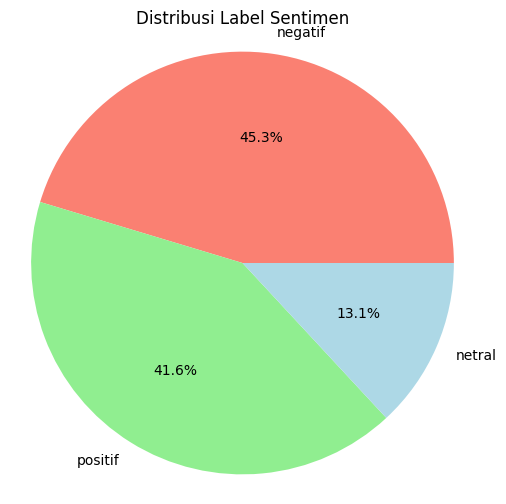

In [ ]:
# melihat distribusi sentimen menggunakan pie chart
label_counts = cleaned_reviews['label'].value_counts()

# buat pie chart
plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=label_counts.index, autopct= '%1.1f%%', colors=['salmon','lightgreen', 'lightblue'])
plt.title('Distribusi Label Sentimen')
plt.axis('equal')
plt.show()

Berdasarkan pie chart diatas, dapat diketahui distribusi label sentimen negatif sebesar 45.3% termasuk tertinggi diantara dua lainnya. Untuk label sentimen positif berada diurutan kedua sebanyak 41.6%, dan terakhir label netral sebanyak 13.1%.

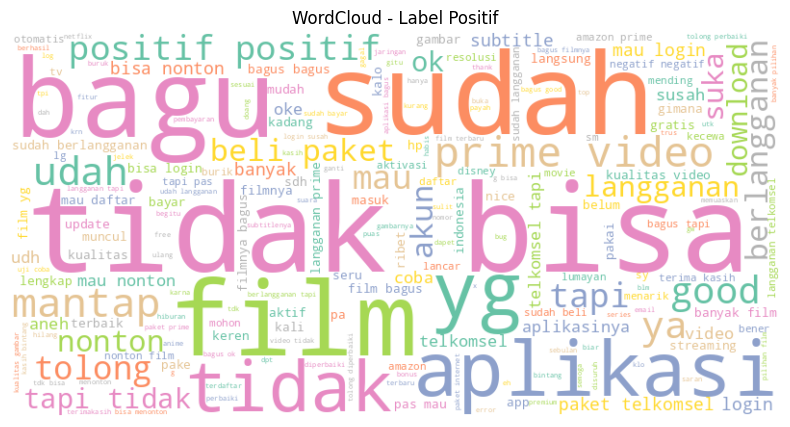

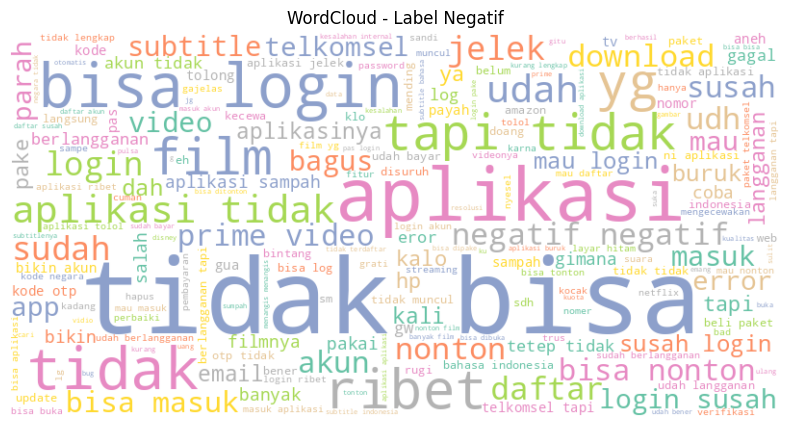

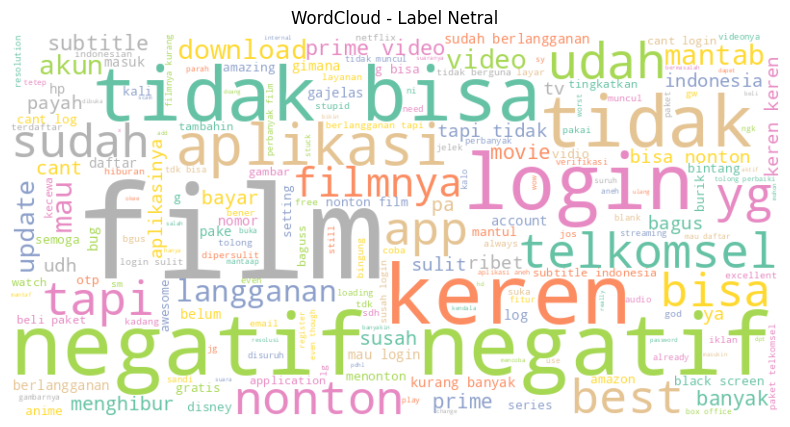

In [ ]:
# melihat wordcloud per label
from wordcloud import WordCloud

def get_words_by_label(label):
  return ' '.join([' '.join(tokens) for tokens in cleaned_reviews[cleaned_reviews['label']== label]['text_stopword']])

# buat wordcloud per label
for label in ['positif', 'negatif', 'netral']:
    text = get_words_by_label(label)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - Label {label.capitalize()}')
    plt.show()

## Data Splitting and Extraction Feature using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
# split feature to review and label
X = cleaned_reviews['text_stemming']
y = cleaned_reviews['label']

# extraction feature using TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=15, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

# convert the result of extraction feature to dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# split data to training data and testing data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
features_df.tail(20)

,akses,aktif,aktivasi,akun,amazon,ampun,aneh,aplikasi,app,atur,...,udh,ulang,update,verifikasi,via,video,vidio,web,ya,yg
14980,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.174795,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14981,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.481932,0.0,0.0,0.000000,0.0,0.000000,0.29852,0.0,0.0,0.0
14982,0.0,0.000000,0.000000,0.569996,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14983,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14984,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14985,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14986,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14987,0.0,0.000000,0.466809,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14988,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0,0.0
14989,0.0,0.276195,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.299021,0.0,0.179971,0.00000,0.0,0.0,0.0


## Modeling - Machine Learning

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# make an object for model
rf_model = RandomForestClassifier()

# training model
rf_model.fit(X_train.toarray(), y_train)

# prediction to train and test data
y_pred_train_rf = rf_model.predict(X_train.toarray())
y_pred_test_rf = rf_model.predict(X_test.toarray())

# evaluation model using accuration
accuracy_train_rf = accuracy_score(y_train, y_pred=y_pred_train_rf)
accuracy_test_rf = accuracy_score(y_test, y_pred=y_pred_test_rf)

# show the accuration of each data
print(f'Accuration train (Random Forest):', accuracy_train_rf)
print(f'Accuration test (Random Forest):', accuracy_test_rf)

Accuration train (Random Forest): 0.9543333333333334
Accuration test (Random Forest): 0.824


### Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# make an object for model
nb_model = MultinomialNB()

# training model
nb_model.fit(X_train.toarray(), y_train)

# prediction to train and test data
y_pred_train_nb = nb_model.predict(X_train.toarray())
y_pred_test_nb = nb_model.predict(X_test.toarray())

# evaluation model using accuration
accuracy_train_nb = accuracy_score(y_train, y_pred=y_pred_train_nb)
accuracy_test_nb = accuracy_score(y_test, y_pred=y_pred_test_nb)

# show the accuration of each data
print(f'Accuration train (Naive Bayes):', accuracy_train_nb)
print(f'Accuration test (Naive Bayes):', accuracy_test_nb)

Accuration train (Naive Bayes): 0.7371666666666666
Accuration test (Naive Bayes): 0.729


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# make an object for model
lg_model = LogisticRegression(max_iter=1000)

# training model
lg_model.fit(X_train.toarray(), y_train)

# prediction to train and test data
y_pred_train_lg = lg_model.predict(X_train.toarray())
y_pred_test_lg = lg_model.predict(X_test.toarray())

# evaluation model using accuration
accuracy_train_lg = accuracy_score(y_train, y_pred=y_pred_train_lg)
accuracy_test_lg = accuracy_score(y_test, y_pred=y_pred_test_lg)

# show the accuration of each data
print(f'Accuration train (Logistic Regression):', accuracy_train_lg)
print(f'Accuration test (Logistic Regression):', accuracy_test_lg)

Accuration train (Logistic Regression): 0.8665
Accuration test (Logistic Regression): 0.848


### SVM

In [ ]:
from sklearn.svm import LinearSVC

# make an object for model
svm_model = LinearSVC(max_iter=1000)

# training model
svm_model.fit(X_train.toarray(), y_train)

# prediction to train and test data
y_pred_train_svm = svm_model.predict(X_train.toarray())
y_pred_test_svm = svm_model.predict(X_test.toarray())

# evaluation model using accuration
accuracy_train_svm = accuracy_score(y_train, y_pred=y_pred_train_svm)
accuracy_test_svm = accuracy_score(y_test, y_pred=y_pred_test_svm)

# show the accuration of each data
print(f'Accuration train (SVM):', accuracy_train_svm)
print(f'Accuration test (SVM):', accuracy_test_svm)

Accuration train (SVM): 0.86775
Accuration test (SVM): 0.8513333333333334
